<a href="https://colab.research.google.com/github/mokshith07271/anomaly-detection/blob/main/notebooks/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install torch torchvision matplotlib

In [22]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mokshithatluri","key":"7e8532b40821952f588433177aeba26d"}'}

In [24]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [27]:
!kaggle datasets download -d ipythonx/mvtec-ad

Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
100% 4.91G/4.91G [00:41<00:00, 128MB/s]



In [28]:
!unzip mvtec-ad.zip

Streaming output truncated to the last 5000 lines.
  inflating: carpet/train/good/149.png  
  inflating: carpet/train/good/150.png  
  inflating: carpet/train/good/151.png  
  inflating: carpet/train/good/152.png  
  inflating: carpet/train/good/153.png  
  inflating: carpet/train/good/154.png  
  inflating: carpet/train/good/155.png  
  inflating: carpet/train/good/156.png  
  inflating: carpet/train/good/157.png  
  inflating: carpet/train/good/158.png  
  inflating: carpet/train/good/159.png  
  inflating: carpet/train/good/160.png  
  inflating: carpet/train/good/161.png  
  inflating: carpet/train/good/162.png  
  inflating: carpet/train/good/163.png  
  inflating: carpet/train/good/164.png  
  inflating: carpet/train/good/165.png  
  inflating: carpet/train/good/166.png  
  inflating: carpet/train/good/167.png  
  inflating: carpet/train/good/168.png  
  inflating: carpet/train/good/169.png  
  inflating: carpet/train/good/170.png  
  inflating: carpet/train/good/171.png  
  infl

In [64]:
import os

categories = os.listdir()   # you already saw this
print(categories)

['.config', 'metal_nut', 'leather', 'cable', 'grid', 'tile', 'zipper', 'pill', 'kaggle.json', 'transistor', 'toothbrush', 'screw', 'readme.txt', 'hazelnut', 'license.txt', 'mvtec-ad.zip', 'carpet', '.ipynb_checkpoints', 'bottle', 'capsule', 'wood', 'sample_data']


In [238]:
import random

category = random.choice(categories)
print("Selected category:", category)

Selected category: zipper


In [239]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

path = category + "/train"

data = datasets.ImageFolder(path, transform=transform)
good_index = data.class_to_idx['good']

good_samples = [sample for sample in data.samples if sample[1] == good_index]

data.samples = good_samples
data.targets = [good_index] * len(good_samples)

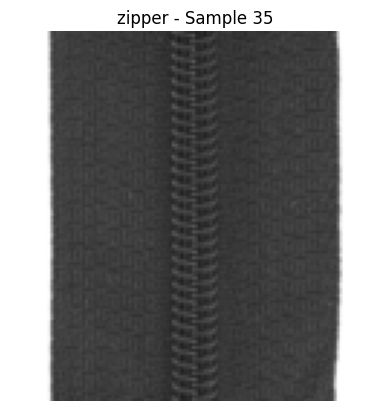

In [240]:
idx = random.randint(0, len(data)-1)
img, label = data[idx]

import matplotlib.pyplot as plt

plt.imshow(img.permute(1,2,0))
plt.title(f"{category} - Sample {idx}")
plt.axis("off")
plt.show()

In [241]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [242]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()

In [243]:
import torch

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:
        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 0.3906
Epoch 2, Loss: 0.3789
Epoch 3, Loss: 0.3593
Epoch 4, Loss: 0.3409
Epoch 5, Loss: 0.3184
Epoch 6, Loss: 0.2927
Epoch 7, Loss: 0.2535
Epoch 8, Loss: 0.1955
Epoch 9, Loss: 0.1384
Epoch 10, Loss: 0.1092


In [244]:
test_data = datasets.ImageFolder(
    category + "/test",
    transform=transform
)

In [245]:
def detect(img):
    img = img.unsqueeze(0)
    output = model(img)

    loss = ((output - img)**2).mean()
    return loss.item(), output

In [246]:
normal_scores = []
anomaly_scores = []

for i in range(len(test_data)):
    img, label = test_data[i]
    score, _ = detect(img)

    if label == 0:
        normal_scores.append(score)
    else:
        anomaly_scores.append(score)

print("Normal:", min(normal_scores), max(normal_scores))
print("Anomaly:", min(anomaly_scores), max(anomaly_scores))

Normal: 0.029405491426587105 0.03221285343170166
Anomaly: 0.029173651710152626 0.03267041966319084


In [247]:
import numpy as np

threshold = np.percentile(normal_scores, 95)

y_true = []
y_pred = []

for i in range(len(test_data)):
    img, label = test_data[i]

    score, _ = detect(img)

    true_label = 0 if label == 0 else 1
    pred_label = 1 if score > threshold else 0

    y_true.append(true_label)
    y_pred.append(pred_label)

In [248]:
import random

idx = random.randint(0, len(test_data)-1)
img, label = test_data[idx]

score, output = detect(img)

print("Anomaly Score:", score)

if score > threshold:
    print("❌ Anomaly Detected")
else:
    print("✅ Normal")

Anomaly Score: 0.031531114131212234
❌ Anomaly Detected


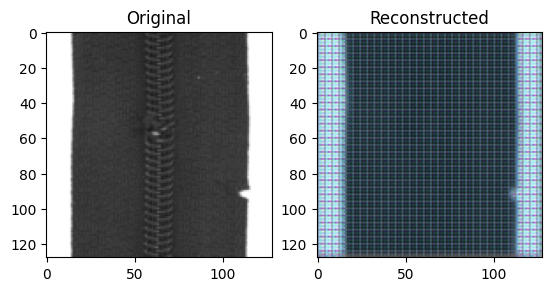

In [249]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(output.squeeze().detach().permute(1,2,0))
plt.title("Reconstructed")

plt.show()

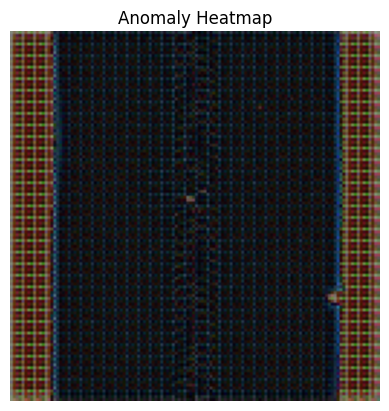

In [250]:
snsndiff = (output.squeeze() - img).abs()

plt.imshow(snsndiff.permute(1,2,0).detach())
plt.title("Anomaly Heatmap")
plt.axis("off")
plt.show()

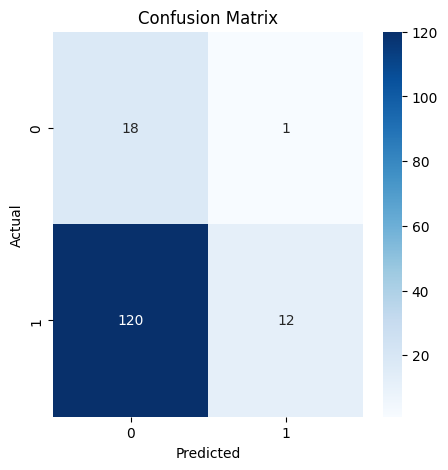

In [251]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()